[*********************100%***********************]  1 of 1 completed


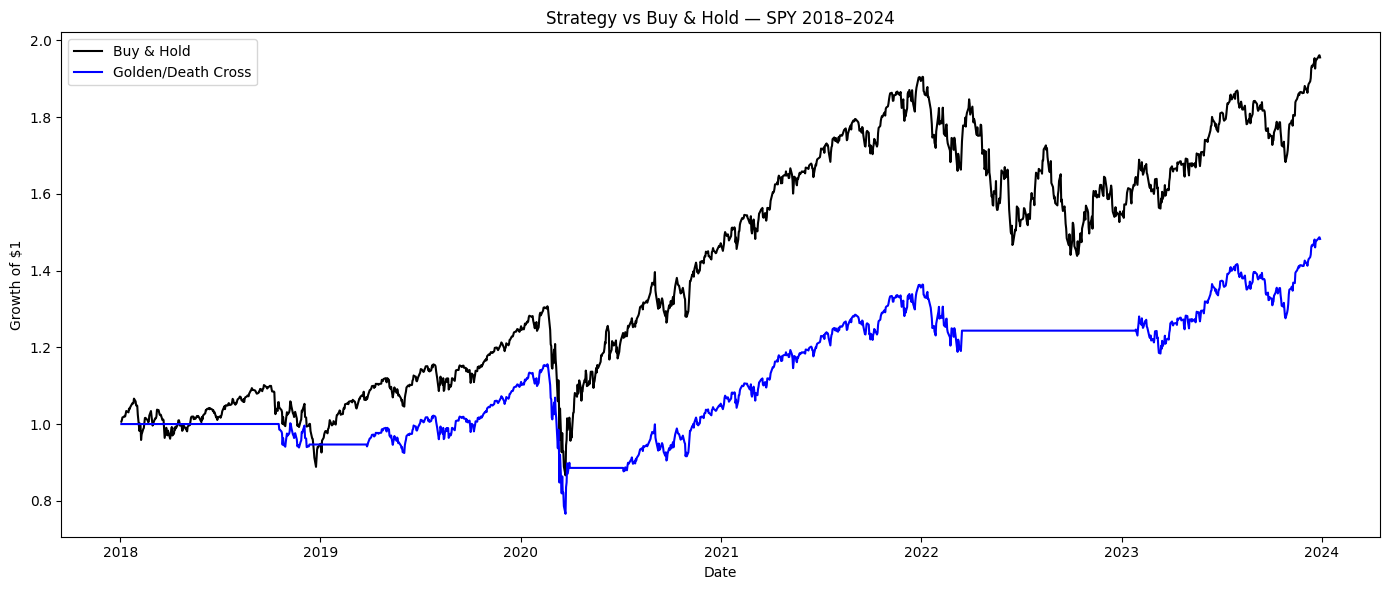

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

spy = yf.download("SPY", start="2018-01-01", end="2024-01-01")
spy['SMA_50'] = spy['Close'].rolling(50).mean()
spy['SMA_200'] = spy['Close'].rolling(200).mean()

spy['Signal'] = (spy['SMA_50'] > spy['SMA_200']).astype(int)
spy['Position'] = spy['Signal'].shift(1).fillna(0)

spy['Market_Return'] = spy['Close'].pct_change()
spy['Strategy_Return'] = spy['Position'] * spy['Market_Return']

spy['Strategy_Cumulative'] = (1 + spy['Strategy_Return']).cumprod()
spy['BuyHold_Cumulative'] = (1 + spy['Market_Return']).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(spy.index, spy['BuyHold_Cumulative'], label='Buy & Hold', color='black')
ax.plot(spy.index, spy['Strategy_Cumulative'], label='Golden/Death Cross', color='blue')
ax.set_title('Strategy vs Buy & Hold — SPY 2018–2024')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1')
ax.legend()
plt.tight_layout()
plt.show()